In [2]:
!pip install matplotlib

55.47s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.5/159.5 kB 3.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 25.8 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.2/309.2 kB 7.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 37.5 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 27.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 43.9 MB/s eta 0:00:00:00:0100:01


In [1]:
#Visualize data output
import matplotlib.pyplot as plt
import json

In [2]:
fp = open("./crunched_numbers_compute.json")
op = json.load(fp)
op.keys()

dict_keys(['local_same_stonewall_latency', 'local_same_stonewall_throughput', 'local_nice_stonewall_latency', 'local_nice_stonewall_throughput', 'local_nice_diff_core_latency', 'local_nice_diff_core_throughput', 'local_prio_diff_core_latency', 'local_prio_diff_core_throughput', 'remote_nice_prio_same_core_latency', 'remote_nice_prio_same_core_throughput', 'local_nice_prio_same_core_latency', 'local_nice_prio_same_core_throughput', 'local_prio_same_core_latency', 'local_prio_same_core_throughput', 'remote_prio_same_core_latency', 'remote_prio_same_core_throughput', 'local_diff_core_latency', 'local_diff_core_throughput', 'remote_nice_same_core_latency', 'remote_nice_same_core_throughput', 'local_nice_same_core_latency', 'local_nice_same_core_throughput', 'local_same_core_latency', 'local_same_core_throughput', 'local_stonewall_latency', 'local_stonewall_throughput', 'remote_diff_core_latency', 'remote_diff_core_throughput', 'remote_same_core_latency', 'remote_same_core_throughput', 'rem

In [3]:
def plot_lat_percentile(experiment):
    data = op[experiment]['latency']['percentile']
    data = {float(k): float(v) for k, v in data.items()}
    y = [i for i in data.keys()]
    x = [data[i] for i in y]
    # Plot CDF
    plt.plot(x, y, label=experiment)
    plt.xlabel("Latency ("+u"\u03bc"+"S)")
    plt.ylabel('ECDF')
    plt.legend(loc="lower right")
    plt.grid(True)

def plot_lat_bar(experiment, name, ax, pos):
    data = op[experiment]['latency']['percentile']
    data = {float(k): float(v)/10**3 for k, v in data.items()}
    boxes = [
        {
            'label' : name,
            'whislo': data[5.00],    # Bottom whisker position
            'q1'    : data[20.0],    # First quartile (25th percentile)
            'med'   : data[50.0],    # Median         (50th percentile)
            'q3'    : data[80.0],    # Third quartile (75th percentile)
            'whishi': data[95.00],    # Top whisker position
            'fliers': []        # Outliers
        }
    ]
    print(boxes)
    ax.bxp(boxes,positions=[pos])
    plt.xlabel("Experiment")
    plt.ylabel('Latency(' + u"\u03bc"+ 'S)')
    plt.grid(True)

def plot_iops_bar(experiment, name):
    y = op[experiment]['iops']['mean']
    y = y / 1000
    plt.bar([name], [y])
    plt.xlabel("Experiment")
    plt.ylabel('KIOPS')
    plt.grid(True)

def plot_bw_bar(experiment, name):
    y = op[experiment]['bw']['mean']
    y = y/1000
    plt.bar([name], [y])
    plt.xlabel("Experiment")
    plt.ylabel('Bandwidth (MBps)')
    plt.grid(True)


Text(0.5, 1.0, 'Local latency CDF')

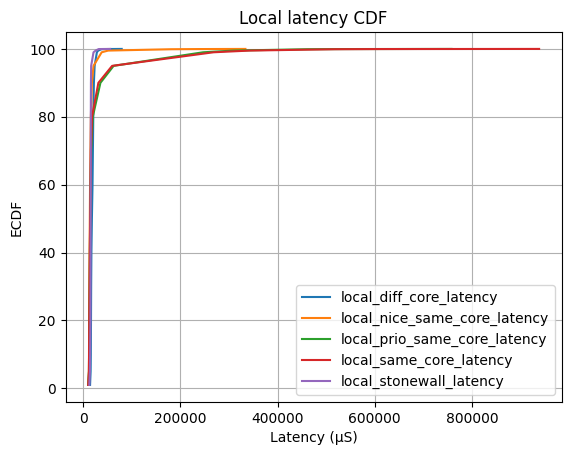

In [4]:
plot_lat_percentile("local_diff_core_latency")
plot_lat_percentile("local_nice_same_core_latency")
plot_lat_percentile("local_prio_same_core_latency")
plot_lat_percentile("local_same_core_latency")
plot_lat_percentile("local_stonewall_latency")
plt.title('Local latency CDF')


Text(0.5, 1.0, 'Local latency CDF')

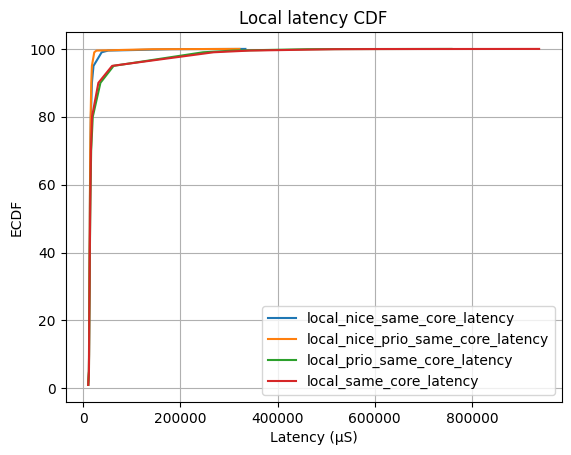

In [5]:
plot_lat_percentile("local_nice_same_core_latency")
plot_lat_percentile("local_nice_prio_same_core_latency")
plot_lat_percentile("local_prio_same_core_latency")
plot_lat_percentile("local_same_core_latency")
plt.title('Local latency CDF')

Text(0.5, 1.0, 'Remote latency CDF')

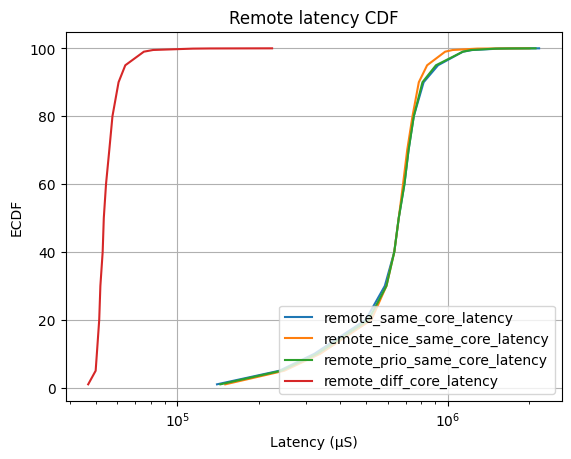

In [6]:
plot_lat_percentile("remote_same_core_latency")
plot_lat_percentile("remote_nice_same_core_latency")
plot_lat_percentile("remote_prio_same_core_latency")
plot_lat_percentile("remote_diff_core_latency")
plt.xscale("log")
plt.title('Remote latency CDF')

[{'label': 'same core', 'whislo': 11.968, 'q1': 12.608, 'med': 14.4, 'q3': 18.304, 'whishi': 59.648, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 11.84, 'q1': 12.352, 'med': 13.76, 'q3': 15.936, 'whishi': 21.376, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 11.84, 'q1': 12.352, 'med': 13.632, 'q3': 15.424, 'whishi': 18.048, 'fliers': []}]
[{'label': 'different core', 'whislo': 15.424, 'q1': 16.192, 'med': 18.048, 'q3': 20.864, 'whishi': 23.68, 'fliers': []}]
[{'label': 'different core (prio)', 'whislo': 15.424, 'q1': 16.192, 'med': 18.048, 'q3': 20.864, 'whishi': 23.424, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 14.016, 'q1': 15.04, 'med': 15.424, 'q3': 15.808, 'whishi': 16.512, 'fliers': []}]


Text(0.5, 1.0, 'Latency for local L-Flow')

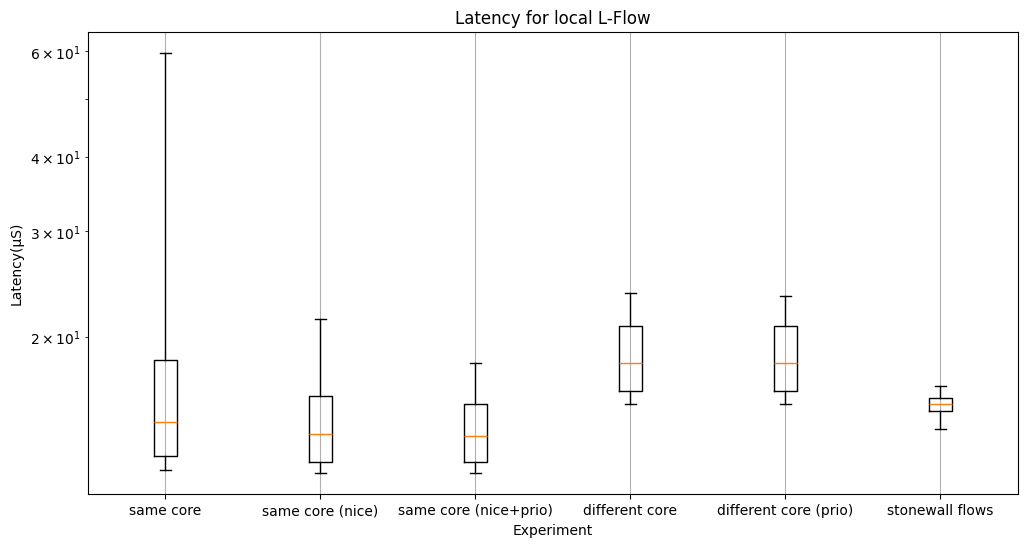

In [7]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=100)


plot_lat_bar("local_same_core_latency","same core", ax, 0)
plot_lat_bar("local_nice_same_core_latency","same core (nice)", ax, 1)
plot_lat_bar("local_nice_prio_same_core_latency", "same core (nice+prio)", ax, 2)
plot_lat_bar("local_diff_core_latency","different core", ax , 3)
plot_lat_bar("local_prio_diff_core_latency","different core (prio)", ax, 4)
#plot_lat_bar("local_same_stonewall_latency","stonewall flows (same)", ax, 5)
plot_lat_bar("local_stonewall_latency", "stonewall flows", ax, 5)
plt.yscale("log")
plt.title('Latency for local L-Flow')

[{'label': 'same core', 'whislo': 238.592, 'q1': 497.664, 'med': 659.456, 'q3': 749.568, 'whishi': 921.6, 'fliers': []}]
[{'label': 'same core (nice)', 'whislo': 248.832, 'q1': 522.24, 'med': 659.456, 'q3': 741.376, 'whishi': 839.68, 'fliers': []}]
[{'label': 'same core (nice+prio)', 'whislo': 257.024, 'q1': 536.576, 'med': 667.648, 'q3': 749.568, 'whishi': 847.872, 'fliers': []}]
[{'label': 'different core', 'whislo': 49.92, 'q1': 51.456, 'med': 53.504, 'q3': 57.6, 'whishi': 64.256, 'fliers': []}]
[{'label': 'stonewall flows', 'whislo': 47.872, 'q1': 49.92, 'med': 51.968, 'q3': 55.552, 'whishi': 64.256, 'fliers': []}]


Text(0.5, 1.0, 'Latency for remote L-Flow')

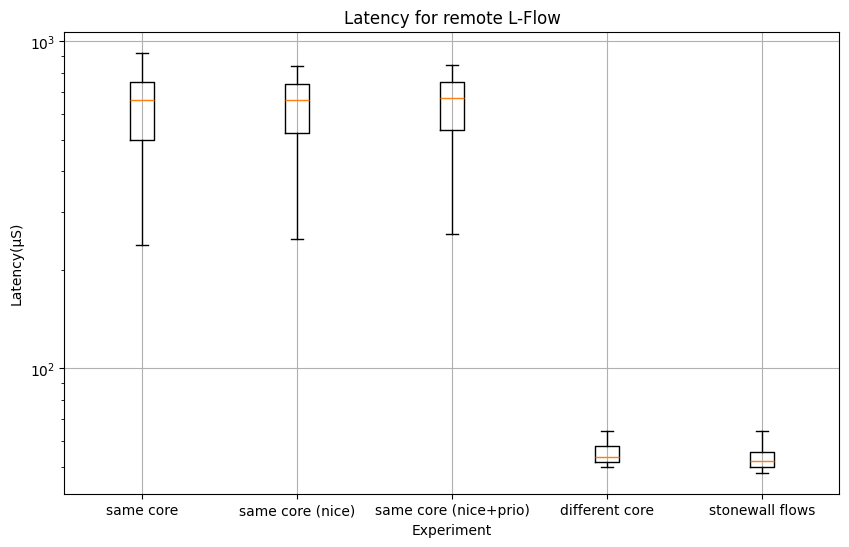

In [8]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
plot_lat_bar("remote_same_core_latency","same core", ax, 0)
plot_lat_bar("remote_nice_same_core_latency","same core (nice)", ax ,1)
#plot_lat_bar("remote_prio_same_core_latency","same core (prio)", ax, 2)
plot_lat_bar("remote_nice_prio_same_core_latency","same core (nice+prio)", ax, 2)
plot_lat_bar("remote_diff_core_latency","different core", ax, 3)
plot_lat_bar("remote_stonewall_latency","stonewall flows", ax, 4)
plt.yscale("log")
plt.title('Latency for remote L-Flow')

Text(0.5, 1.0, 'IOPS bar graph for local T-Flow')

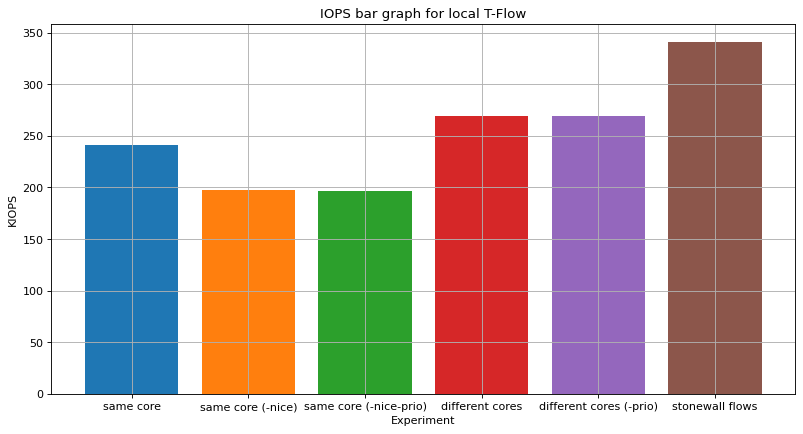

In [9]:
plt.figure(figsize=(12, 6), dpi=80)
plot_iops_bar("local_same_core_throughput","same core")
plot_iops_bar("local_nice_same_core_throughput","same core (-nice)")
plot_iops_bar("local_nice_prio_same_core_throughput","same core (-nice-prio)")
plot_iops_bar("local_diff_core_throughput","different cores")
plot_iops_bar("local_prio_diff_core_throughput","different cores (-prio)")
plot_iops_bar("local_stonewall_throughput","stonewall flows")
plt.title('IOPS bar graph for local T-Flow')


Text(0.5, 1.0, 'IOPS bar graph for remote T-Flow')

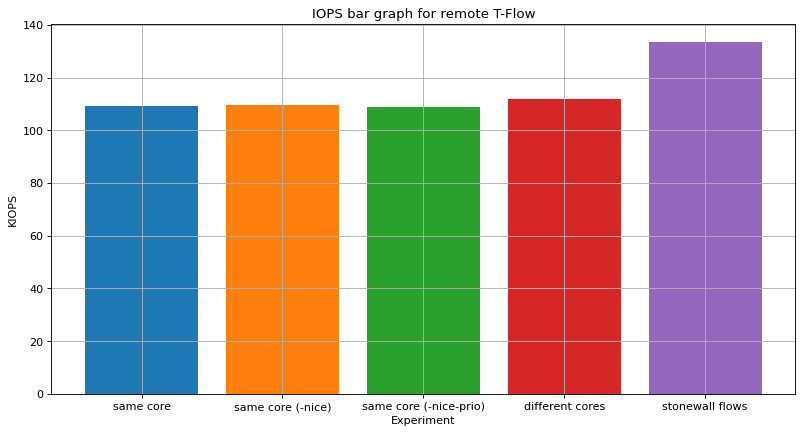

In [10]:
plt.figure(figsize=(12, 6), dpi=80)
plot_iops_bar("remote_same_core_throughput","same core")
plot_iops_bar("remote_nice_same_core_throughput","same core (-nice)")
plot_iops_bar("remote_nice_prio_same_core_throughput","same core (-nice-prio)")
plot_iops_bar("remote_diff_core_throughput","different cores")
#plot_iops_bar("remote_prio_diff_core_throughput","different cores (-prio)")
plot_iops_bar("remote_stonewall_throughput","stonewall flows")
plt.title('IOPS bar graph for remote T-Flow')
